# RPM Calculation from `pg_rpm` Pulse Signal

This notebook demonstrates how to calculate the actual motor rotational speed (RPM)
from the `pg_rpm` pulse signal column in the OpenBLDCData dataset.

**Key fact:** The motor driver outputs **6 pulses per one full mechanical revolution**.
By counting pulse edges (rising transitions from 0 → 1) within a time window,
we can estimate the instantaneous RPM.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [13]:
df = pd.read_csv('../data/analize_healthy10_1000rpm_64mA_bat.csv')

# t_us is in microseconds — convert to seconds
df['t_s'] = df['t_us'] * 1e-6

print(f"Samples: {len(df)}")
print(f"Duration: {df['t_s'].iloc[-1]:.2f} s")

Samples: 262389
Duration: 262.39 s


## Rising Edge Detection and Pulse Timestamp Extraction

The raw digital output from the motor position sensor is sampled at discrete intervals, yielding a binary sequence $s[k] \in \{0, 1\}$, where $k$ denotes the sample index. For the present motor configuration, each complete mechanical revolution produces exactly six discrete signal transitions.

Rising edges (0 $\to$ 1 transitions) are detected to isolate individual pulse events. This is achieved by evaluating the state change between consecutive samples. Formally, the edge indicator $e[k]$ is defined as
$$
e[k] = \mathbb{I}\{s[k-1] = 0 \,\wedge\, s[k] = 1\},
$$
where $\mathbb{I}\{\cdot\}$ denotes the indicator function. This formulation identifies precisely the sampling instants at which the signal transitions from low to high state, effectively filtering out steady-state periods and falling edges.

The timestamps associated with detected rising edges are extracted to construct the ordered sequence $\{t_k\}_{k=1}^{M}$, where $M$ is the total number of identified pulses. This pulse timing series serves as the foundational input for all subsequent rotational speed calculations. The total number of completed mechanical revolutions is then derived as $N_{\text{rev}} = M / 6$, establishing a direct quantitative link between the digital pulse count and the physical rotor displacement.

In [14]:
PULSES_PER_REV = 6
rising_edge = (df['pg_rpm'].shift(1) == 0) & (df['pg_rpm'] == 1)
pulse_times = df.loc[rising_edge, 't_s'].values

print(f"Total pulses detected: {len(pulse_times)}")
print(f"Total revolutions: {len(pulse_times) / PULSES_PER_REV:.1f}")

Total pulses detected: 26130
Total revolutions: 4355.0


## Estimation of Instantaneous Rotational Speed from Encoder Pulses

The instantaneous rotational speed is derived from the temporal spacing of encoder pulse edges. Given a sensor resolution of $N=6$ pulses per mechanical revolution, the duration of each full revolution is computed as the time difference between pulse events separated by $N$ indices. Formally, for a sequence of pulse timestamps $\{t_k\}$, the $i$-th revolution period is obtained as

$$
T_{\mathrm{rev},\,i} = t_{i+N} - t_{i}, \qquad i = 1, 2, \dots, M-N,
$$

where $M$ denotes the total number of detected pulses. This vectorized formulation enables efficient computation over the entire recording without explicit iteration.

The corresponding rotational speed in revolutions per minute is then

$$
\mathrm{RPM}_i = \frac{60}{T_{\mathrm{rev},\,i}}.
$$

Each speed estimate is temporally referenced to the timestamp marking the *completion* of the respective revolution, i.e., $t_{\mathrm{RPM},\,i} = t_{i+N}$. This convention ensures that the reported speed value reflects the average angular velocity over the immediately preceding interval $[t_i,\, t_{i+N}]$.

### Descriptive Statistics of the RPM Sequence

To characterize the central tendency and dispersion of the estimated rotational speed, the following descriptive statistics are computed from the sequence $\{\mathrm{RPM}_i\}_{i=1}^{n}$, where $n = M - N$ is the total number of revolution periods:

**Sample Mean** (central tendency):
$$
\overline{\mathrm{RPM}} = \frac{1}{n}\sum_{i=1}^{n} \mathrm{RPM}_i
$$
The arithmetic mean provides an estimate of the expected rotational speed over the observation interval.

**Sample Standard Deviation** (dispersion):
$$
s_{\mathrm{RPM}} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\left(\mathrm{RPM}_i - \overline{\mathrm{RPM}}\right)^2}
$$
The standard deviation quantifies the typical magnitude of speed fluctuations around the mean, serving as a measure of short-term speed stability.

**Minimum and Maximum** (range):
$$
\mathrm{RPM}_{\min} = \min\{\mathrm{RPM}_1, \mathrm{RPM}_2, \dots, \mathrm{RPM}_n\}, \qquad \mathrm{RPM}_{\max} = \max\{\mathrm{RPM}_1, \mathrm{RPM}_2, \dots, \mathrm{RPM}_n\}
$$
The extreme values define the observed operational range and are particularly useful for identifying transient deviations or outliers in the speed profile.


In [27]:


rev_dt = pulse_times[PULSES_PER_REV:] - pulse_times[:-PULSES_PER_REV]
rpm_values = 60.0 / rev_dt
rpm_times  = pulse_times[PULSES_PER_REV:]  # timestamp at the end of each revolution
mean_rpm = rpm_values.mean()

print(f"Mean RPM : {mean_rpm:.1f}")
print(f"Std  RPM : {rpm_values.std():.1f}")
print(f"Min  RPM : {rpm_values.min():.1f}")
print(f"Max  RPM : {rpm_values.max():.1f}")

Mean RPM : 995.9
Std  RPM : 7.1
Min  RPM : 982.5
Max  RPM : 1001.2


### Temporal Stability of Estimated Rotational Speed

The temporal evolution of the estimated rotational speed, computed from encoder pulse timing, is presented in the figure below. The plot displays the instantaneous RPM trace over the recording interval, with a horizontal reference line indicating the sample mean. Visual inspection reveals short-term fluctuations around the mean value; however, interpreting these variations requires distinguishing between genuine mechanical dynamics and measurement-induced uncertainty.

To establish a quantitative baseline for expected jitter, we derive the theoretical uncertainty propagated from the finite temporal resolution of the sampling system. This analysis provides a reference against which the observed speed variations can be assessed.


#### Derivation of RPM Uncertainty from Sampling Quantization

The instantaneous rotational speed is estimated from encoder pulse timing using a sampling frequency of $f_s=1\,\mathrm{kHz}$, corresponding to a temporal resolution of $T_s=1\,\mathrm{ms}$. Given six pulses per mechanical revolution, the revolution period is computed as $T_{\mathrm{rev}} = t_{k+6}-t_k$, from which the rotational speed follows as $\mathrm{RPM}=60/T_{\mathrm{rev}}$.

Because timestamps are quantized to the discrete sampling grid, the period estimate inherits an inherent timing uncertainty. Under the assumption of uniform quantization error, the maximum deviation is bounded by $|\Delta T_{\mathrm{rev}}|_{\max}\approx T_s$, while the standard deviation may be approximated as $\sigma_{T_{\mathrm{rev}}}\approx T_s/\sqrt{2}$. Propagation of this uncertainty to the RPM estimate is obtained via first-order sensitivity analysis. Differentiating the relation $\mathrm{RPM}=60/T$ yields

$$
\Delta\mathrm{RPM} \approx \left|\frac{d}{dT}\left(\frac{60}{T}\right)\right|\Delta T_{\mathrm{rev}} = \frac{60}{T_{\mathrm{rev}}^2}\,\Delta T_{\mathrm{rev}} = \frac{\mathrm{RPM}^2}{60}\,\Delta T_{\mathrm{rev}}.
$$

Using the observed mean rotational speed of $995.9\,\mathrm{RPM}$ as a representative value, the expected root-mean-square uncertainty due to sampling quantization is

$$
\sigma_{\mathrm{RPM}} \approx \frac{995.9^2}{60} \cdot \frac{0.001}{\sqrt{2}} \approx 11.7\,\mathrm{RPM},
$$

while a conservative worst-case bound, assuming the maximum timing error $\pm T_s$, is

$$
|\Delta\mathrm{RPM}|_{\max} \approx \frac{995.9^2}{60} \cdot 0.001 \approx 16.5\,\mathrm{RPM}.
$$

These theoretical estimates can be contextualized against the observed statistics from the recording: mean $995.9\,\mathrm{RPM}$, standard deviation $7.1\,\mathrm{RPM}$, minimum $982.5\,\mathrm{RPM}$, and maximum $1001.2\,\mathrm{RPM}$. The observed standard deviation ($7.1\,\mathrm{RPM}$) lies below the predicted RMS uncertainty ($11.7\,\mathrm{RPM}$), and the full observed range ($982.5$ to $1001.2\,\mathrm{RPM}$) remains within the conservative worst-case bound of approximately $\pm 16.5\,\mathrm{RPM}$ around the mean.

This agreement indicates that short-term RPM variations on the order of $\pm(10\text{ to }20)\,\mathrm{RPM}$ arise naturally from the finite temporal resolution of the measurement system, independent of mechanical speed fluctuations. **Consequently, observed jitter within this range should be interpreted as a measurement artifact rather than as evidence of motor instability.** The derived uncertainty baseline thus provides a principled reference for distinguishing genuine dynamic behavior from quantization-induced noise in subsequent analyses.

The figure below visualizes this temporal stability, where the red dotted line denotes the mean rotational speed ($995.9\,\mathrm{RPM}$) and the blue trace represents the instantaneous RPM estimate. The observed fluctuations align with the theoretically predicted uncertainty bounds derived above.

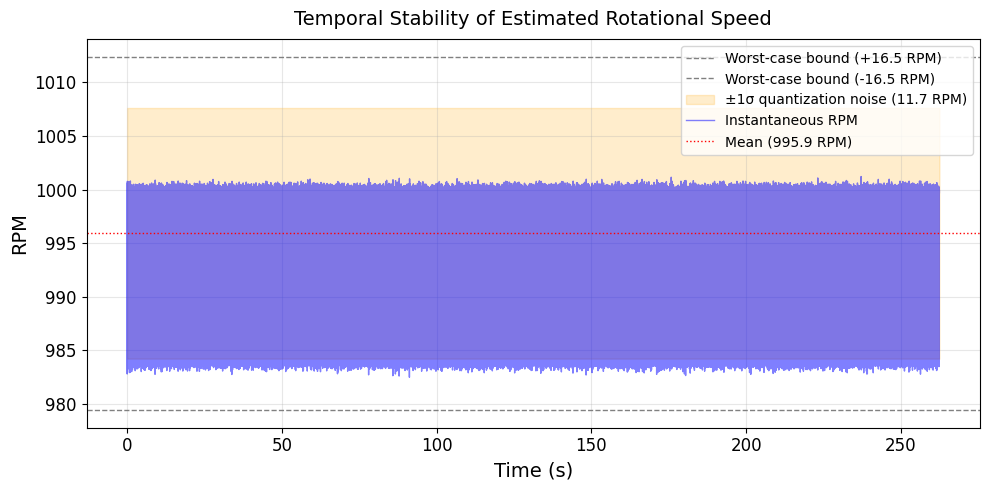

In [28]:

rms_uncertainty = 11.7
worst_case_bound = 16.5

plt.figure(figsize=(10, 5))
plt.axhline(y=mean_rpm + worst_case_bound, color='gray', linestyle='--', linewidth=1, label=f'Worst-case bound (+{worst_case_bound} RPM)')
plt.axhline(y=mean_rpm - worst_case_bound, color='gray', linestyle='--', linewidth=1, label=f'Worst-case bound (-{worst_case_bound} RPM)')
plt.fill_between(rpm_times, 
                 mean_rpm - rms_uncertainty, 
                 mean_rpm + rms_uncertainty, 
                 color='orange', alpha=0.2, 
                 label=f'±1σ quantization noise ({rms_uncertainty:.1f} RPM)',
                 zorder=1) 
plt.plot(rpm_times, rpm_values, linestyle='-', color='blue', linewidth=1, alpha=0.5, label='Instantaneous RPM', zorder=2)
plt.axhline(y=mean_rpm, color='red', linestyle=':', linewidth=1, label=f'Mean ({mean_rpm:.1f} RPM)')

plt.title('Temporal Stability of Estimated Rotational Speed', fontsize=14, pad=10)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('RPM', fontsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=12)

plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## Summary

| Step | Description |
| --- | --- |
| 1 | Read `t_us` (timestamp in µs) and `pg_rpm` (0/1 pulse) columns |
| 2 | Detect rising edges (0 → 1 transitions) to find pulse timestamps |
| 3 | Group 6 consecutive pulses = 1 mechanical revolution |
| 4 | $\text{RPM} = 60 / \Delta t_{\text{revolution}}$ |

